# Genetic Algorithm
Note: <br>
For this algorithm to run the clients, employees and their nearest_segments have to be calculated in advance.

Genetic representation: <br>
List of clients in order of being calculated.

Mutation: <br>
Swap mutation to change the path randomly. Each mutation will use one parent to make sure no duplicate clients get added.

Tournament selection: <br>
Used to get a fair spread of good and bad states.

Elitism survivor selection: <br>
To make sure we do not go back in progress.

In [48]:
from pathlib import Path
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import osmnx as ox
import numpy as np
from shapely import wkt
import networkx as nx
from itertools import pairwise
from shapely.geometry import LineString

# Importing and cleaning

In [49]:
# Load data
clients_df = pd.read_csv("../output/clients.csv")
employees_df = pd.read_csv("../output/employees.csv")
clients_nearest_segments = pd.read_csv("../output/client_nearest_segments.csv")
employees_nearest_segments = pd.read_csv("../output/employee_nearest_segments.csv")
heerlen_edge_table = pd.read_csv("../output/heerlen_edge_table.csv")

In [50]:
# Combine clients
clients_nearest_segments = clients_nearest_segments.rename(columns={"client_name": "name"})
clients_df = clients_df.merge(clients_nearest_segments, on="name", how="left")

# Keep the base client columns and remove duplicate right-side columns from merge.
clients_df = clients_df.drop(columns=["address_y", "coordinates_y"], errors="ignore")
clients_df = clients_df.rename(
    columns={
        "address_x": "address",
        "coordinates_x": "coordinates",
    }
)

# Parse coordinates in "lat lon" format into numeric columns used by downstream cells.
if "coordinates" in clients_df.columns:
    coord_parts = clients_df["coordinates"].astype(str).str.strip().str.split(r"\s+", n=1, expand=True)
    if coord_parts.shape[1] == 2:
        clients_df["lat"] = pd.to_numeric(coord_parts[0], errors="coerce")
        clients_df["lon"] = pd.to_numeric(coord_parts[1], errors="coerce")

clients_df.head(3)

,name,address,coordinates,care_arrangement,preferences,time_window_start,time_window_end,care_hours,dogs,cats,smokes,edge_id,u,v,key,edge_name,highway,distance_m,lat,lon
0,Client 1,"Putgraaf 478, 6411KN Heerlen",50.8870305 5.9850058,HBH Basic,morning,08:00,12:00,3.0,1,0,False,2164,42033003,42032089,0,Groene Boord,tertiary,30.806634,50.887031,5.985006
1,Client 2,"Tulpstraat 63-GB04, Heerlen",50.9235901 5.9630637,HBH Plus,afternoon,12:00,18:00,2.5,0,0,False,5109,42071791,42071604,0,Asterstraat | Tulpstraat,residential,30.541292,50.923590,5.963064
2,Client 2,"Tulpstraat 63-GB04, Heerlen",50.9235901 5.9630637,HBH Plus,afternoon,12:00,18:00,2.5,0,0,False,5093,42071604,42071791,0,Asterstraat | Tulpstraat,residential,30.541292,50.923590,5.963064


In [51]:
# Combine employees
employees_nearest_segments = employees_nearest_segments.rename(columns={'employee_name': 'name'})
employees_df = employees_df.merge(employees_nearest_segments, on="name", how="left")

# Keep the base employee columns and remove duplicate right-side columns from merge.
employees_df = employees_df.drop(columns=["address_y", "coordinates_y"], errors="ignore")
employees_df = employees_df.rename(
    columns={
        "address_x": "address",
        "coordinates_x": "coordinates",
    }
)

# Parse coordinates in "lat lon" format into numeric columns used by downstream cells.
if "coordinates" in employees_df.columns:
    coord_parts = employees_df["coordinates"].astype(str).str.strip().str.split(r"\s+", n=1, expand=True)
    if coord_parts.shape[1] == 2:
        employees_df["lat"] = pd.to_numeric(coord_parts[0], errors="coerce")
        employees_df["lon"] = pd.to_numeric(coord_parts[1], errors="coerce")

employees_df.head(3)

,name,address,coordinates,time_window_start,time_window_end,dogs,cats,smokes,edge_id,u,v,key,edge_name,highway,distance_m,lat,lon
0,employee 1,"Dr. de Visserstraat 6, 6415HJ Heerlen",50.8979843 5.9881059,07:00,18:00,2,-1,True,3133,42045886,42044822,0,Doctor de Visserstraat,residential,8.102585,50.897984,5.988106
1,employee 1,"Dr. de Visserstraat 6, 6415HJ Heerlen",50.8979843 5.9881059,07:00,18:00,2,-1,True,2982,42044822,42045886,0,Doctor de Visserstraat,residential,8.102585,50.897984,5.988106
2,employee 2,"Geerstraat 258, 6411NW Heerlen",50.8884582 5.9736771,07:00,18:00,-1,1,False,5617,1505263383,42033188,0,Geerstraat,residential,14.356675,50.888458,5.973677


# Setup Genetic Algorithm

In [52]:
# Initialize all necessary parts of the genetic algorithm
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

POPULATION_SIZE = 100
EPOCHS = 500

MUTATION_RATE = 1.00
MUTATION_STRIDE = 2

TOURNAMENT_SIZE = 5
ELITE_SIZE = max(1, int(0.10 * POPULATION_SIZE))

MAX_EMPLOYEE_WORK_TIME_MIN = 8 * 60

print("GA initialized:")
print(f"  seed={RANDOM_SEED}, population={POPULATION_SIZE}, epochs={EPOCHS}")
print(f"  mutation_rate={MUTATION_RATE}, mutation_stride={MUTATION_STRIDE}")
print(f"  tournament={TOURNAMENT_SIZE}, elite_size={ELITE_SIZE}")

GA initialized:
  seed=42, population=100, epochs=500
  mutation_rate=1.0, mutation_stride=2
  tournament=5, elite_size=10


In [53]:
# ============= Initial Population =============
NUM_CLIENTS = len(clients_df)
client_indices = list(range(NUM_CLIENTS))
initial_population = [np.random.permutation(client_indices).tolist() for _ in range(POPULATION_SIZE)]

print(f"Initialized population with {len(initial_population)} individuals.")
print(f"Each individual contains {len(initial_population[0])} client indices.")
print(f"Total clients in dataset: {NUM_CLIENTS}")
print("First individual:")
print(initial_population[0])

Initialized population with 100 individuals.
Each individual contains 161 client indices.
Total clients in dataset: 161
First individual:
[105, 108, 142, 55, 94, 29, 101, 51, 100, 143, 19, 84, 15, 66, 24, 30, 128, 148, 98, 16, 75, 18, 12, 9, 31, 152, 97, 56, 132, 104, 137, 78, 60, 115, 2, 123, 45, 42, 69, 90, 26, 139, 82, 96, 131, 36, 81, 22, 144, 67, 114, 11, 65, 85, 6, 27, 76, 140, 126, 41, 4, 136, 32, 127, 133, 68, 10, 95, 109, 0, 119, 111, 64, 44, 86, 28, 40, 112, 25, 23, 117, 79, 39, 93, 157, 156, 135, 47, 153, 61, 73, 33, 120, 118, 125, 62, 159, 149, 154, 53, 5, 150, 124, 49, 35, 80, 77, 34, 46, 7, 43, 70, 122, 110, 91, 83, 145, 146, 89, 8, 113, 13, 59, 138, 3, 17, 38, 72, 141, 134, 147, 63, 54, 107, 50, 158, 58, 48, 88, 21, 57, 155, 129, 37, 151, 1, 52, 130, 103, 99, 116, 87, 74, 121, 160, 20, 71, 106, 14, 92, 102]


In [54]:
# ============= Mutation Function =============
def swap_mutation(parent):
    """
    Swap mutation: takes a single parent (list of client indices),
    creates a mutant by swapping MUTATION_STRIDE random position pairs.
    
    Args:
        parent: list of client indices representing a route order
        
    Returns:
        mutant: mutated copy of parent with swapped positions
    """
    mutant = parent.copy()
    
    # Perform MUTATION_STRIDE swaps
    for _ in range(MUTATION_STRIDE):
        # Select two random distinct indices
        i, j = np.random.choice(len(mutant), size=2, replace=False)
        # Swap them
        mutant[i], mutant[j] = mutant[j], mutant[i]
    
    return mutant

In [55]:
# ============= Tournament Selection =============
def tournament_selection(population, fitness_scores):
    """
    Tournament selection: randomly sample TOURNAMENT_SIZE individuals
    and return the best one (lower fitness is better for minimization).
    
    Args:
        population: list of individuals (each individual is a list of client indices)
        fitness_scores: list of fitness values corresponding to each individual
        
    Returns:
        winner: selected individual from the tournament
        winner_fitness: fitness score of the selected individual
    """
    # Sample unique indices for the tournament
    tournament_size = min(TOURNAMENT_SIZE, len(population))
    candidate_indices = np.random.choice(len(population), size=tournament_size, replace=False)
    
    # Find index of the best candidate in the sampled set (lower fitness is better)
    best_local_idx = np.argmin([fitness_scores[i] for i in candidate_indices])
    winner_index = candidate_indices[best_local_idx]
    
    winner = population[winner_index]
    winner_fitness = fitness_scores[winner_index]
    
    return winner, winner_fitness

In [56]:
# ============= Elitism Selection =============
def elitism_selection(population, fitness_scores):
    """
    Elitism selection: preserve the top ELITE_SIZE individuals from the population
    based on their fitness scores (lower fitness is better for minimization).
    
    Args:
        population: list of individuals (each individual is a list of client indices)
        fitness_scores: list of fitness values corresponding to each individual
        
    Returns:
        elite_individuals: list of the ELITE_SIZE best individuals
        elite_fitness: list of fitness scores for the elite individuals
    """
    # Get indices sorted by fitness (ascending - lower is better)
    sorted_indices = np.argsort(fitness_scores)[:ELITE_SIZE]
    
    # Extract elite individuals and their fitness scores
    elite_individuals = [population[i] for i in sorted_indices]
    elite_fitness = [fitness_scores[i] for i in sorted_indices]
    
    return elite_individuals, elite_fitness

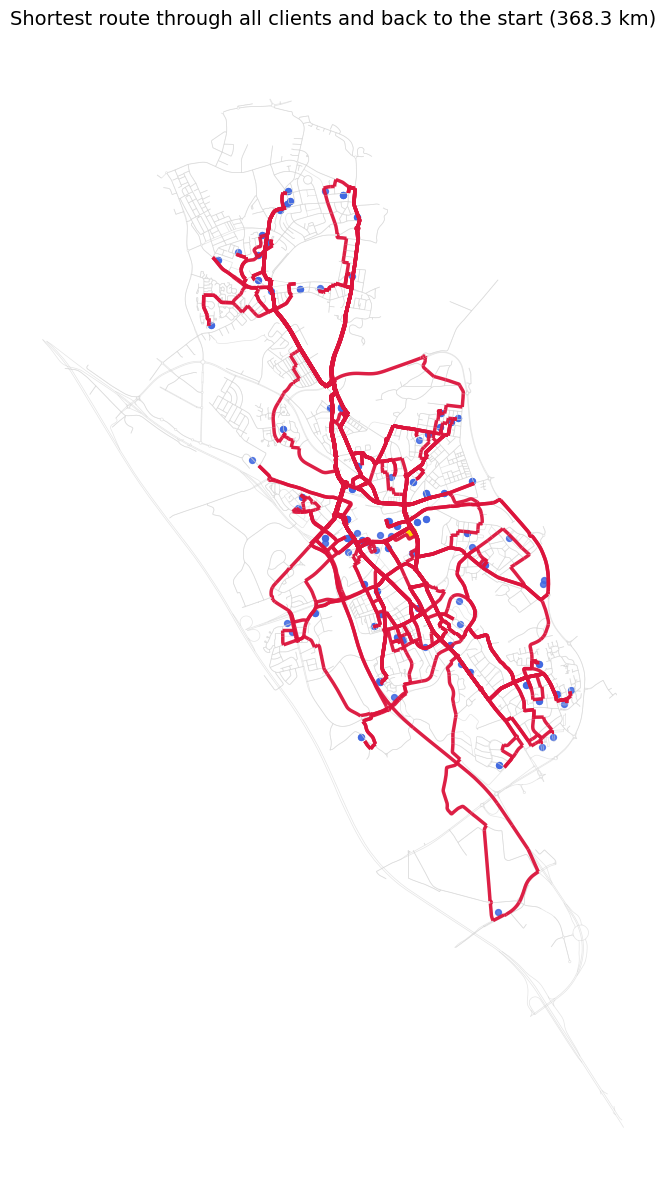

In [57]:
# TEST: Go through every client in the current dataset and return to the start.
# Build a road graph from the edge table that already has corrected geometry direction.
road_graph = nx.MultiDiGraph()
road_graph.graph["crs"] = "EPSG:4326"

# Ensure GeoDataFrames exist (use data already loaded in other cells).
if "edges_gdf" not in globals():
    if "geometry" not in heerlen_edge_table.columns:
        raise ValueError("heerlen_edge_table must contain a 'geometry' column to build edges_gdf.")
    _edges = heerlen_edge_table.copy()
    _edges["geometry"] = _edges["geometry"].apply(
        lambda g: wkt.loads(g) if isinstance(g, str) else g
)
    edges_gdf = gpd.GeoDataFrame(_edges, geometry="geometry", crs="EPSG:4326")

if "clients_gdf" not in globals():
    _clients = clients_df.copy()
    if "geometry" in _clients.columns:
        _clients["geometry"] = _clients["geometry"].apply(
            lambda g: wkt.loads(g) if isinstance(g, str) else g
)
        clients_gdf = gpd.GeoDataFrame(_clients, geometry="geometry", crs="EPSG:4326")
    elif "coordinates" in _clients.columns:
        coordinate_parts = _clients["coordinates"].astype(str).str.strip().str.split(r"\s+", n=1, expand=True)
        if coordinate_parts.shape[1] != 2:
            raise ValueError("clients_df.coordinates must contain latitude and longitude separated by a space.")
        _clients["lat"] = pd.to_numeric(coordinate_parts[0], errors="coerce")
        _clients["lon"] = pd.to_numeric(coordinate_parts[1], errors="coerce")
        clients_gdf = gpd.GeoDataFrame(
            _clients,
            geometry=gpd.points_from_xy(_clients["lon"], _clients["lat"]),
            crs="EPSG:4326",
)
    else:
        lon_col = next((c for c in ["lon", "longitude", "x"] if c in _clients.columns), None)
        lat_col = next((c for c in ["lat", "latitude", "y"] if c in _clients.columns), None)
        if lon_col is None or lat_col is None:
            raise ValueError("clients_df needs either a geometry column, coordinates column, or lon/lat columns.")
        clients_gdf = gpd.GeoDataFrame(
            _clients,
            geometry=gpd.points_from_xy(_clients[lon_col], _clients[lat_col]),
            crs="EPSG:4326",
)

# Build graph from edges_gdf.
for edge_idx, edge_row in edges_gdf.iterrows():
    geometry = edge_row["geometry"]
    if geometry is None or geometry.is_empty:
        continue

    line_parts = list(geometry.geoms) if geometry.geom_type == "MultiLineString" else [geometry]
    edge_attributes = edge_row.drop(labels=["geometry", "key"], errors="ignore").to_dict()

    for line in line_parts:
        coordinates = list(line.coords)
        if len(coordinates) < 2:
            continue

        start_x, start_y = coordinates[0]
        end_x, end_y = coordinates[-1]
        u = int(edge_row["u"])
        v = int(edge_row["v"])
        k = edge_row["key"] if "key" in edges_gdf.columns else edge_idx

        road_graph.add_node(u, x=float(start_x), y=float(start_y))
        road_graph.add_node(v, x=float(end_x), y=float(end_y))

        if "length" not in edge_attributes or pd.isna(edge_attributes["length"]):
            edge_attributes["length"] = float(line.length)

        road_graph.add_edge(u, v, key=k, geometry=line, **edge_attributes)

# Route through every client in row order and return to the first client.
route_client_points = clients_gdf.iloc[: len(clients_gdf)].copy()
if route_client_points.empty:
    raise ValueError("clients_gdf is empty, so no route can be built.")

route_client_points = pd.concat([route_client_points, route_client_points.iloc[[0]]], ignore_index=True)
route_client_nodes = ox.nearest_nodes(
    road_graph,
    route_client_points.geometry.x.to_list(),
    route_client_points.geometry.y.to_list(),
)

route_geometries = []
route_total_length_m = 0.0

for start_node, end_node in pairwise(route_client_nodes):
    path_nodes = nx.shortest_path(road_graph, start_node, end_node, weight="length")
    route_total_length_m += nx.path_weight(road_graph, path_nodes, weight="length")

    for node_u, node_v in pairwise(path_nodes):
        edge_bundle = road_graph.get_edge_data(node_u, node_v)
        if not edge_bundle:
            route_geometries.append(
                LineString(
                    [
                        (road_graph.nodes[node_u]["x"], road_graph.nodes[node_u]["y"]),
                        (road_graph.nodes[node_v]["x"], road_graph.nodes[node_v]["y"]),
                    ]
                )
            )
            continue

        best_key = min(
            edge_bundle,
            key=lambda candidate_key: edge_bundle[candidate_key].get("length", float("inf")),
        )
        selected_edge = edge_bundle[best_key]
        geometry = selected_edge.get("geometry")
        if geometry is None:
            geometry = LineString(
                [
                    (road_graph.nodes[node_u]["x"], road_graph.nodes[node_u]["y"]),
                    (road_graph.nodes[node_v]["x"], road_graph.nodes[node_v]["y"]),
                ]
            )
        route_geometries.append(geometry)

route_gdf = gpd.GeoDataFrame(geometry=route_geometries, crs="EPSG:4326").to_crs(epsg=3857)
edges_plot = edges_gdf.to_crs(epsg=3857)
clients_plot = clients_gdf.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(12, 12))
edges_plot.plot(ax=ax, color="lightgray", linewidth=0.5, alpha=0.6)
route_gdf.plot(ax=ax, color="crimson", linewidth=2.5, alpha=0.95)
clients_plot.plot(ax=ax, color="royalblue", markersize=18, alpha=0.85)
clients_plot.iloc[[0]].plot(ax=ax, color="gold", markersize=50, alpha=1.0)

ax.set_title(
    f"Shortest route through all clients and back to the start ({route_total_length_m / 1000:.1f} km)",
    fontsize=14,
)
ax.set_axis_off()
plt.tight_layout()
plt.show()

In [58]:
# Reusable shortest-route helper for any start and end node.
def get_route_between_nodes(road_graph, start_node, end_node, weight="travel_time_min"):
    """Return the shortest path and total weight between two nodes."""
    if start_node not in road_graph or end_node not in road_graph:
        raise ValueError("Both start_node and end_node must exist in the graph.")

    path_nodes = nx.shortest_path(road_graph, start_node, end_node, weight=weight)
    route_value = nx.path_weight(road_graph, path_nodes, weight=weight)

    route_geometries = []
    for node_u, node_v in pairwise(path_nodes):
        edge_bundle = road_graph.get_edge_data(node_u, node_v)
        if not edge_bundle:
            route_geometries.append(
                LineString(
                    [
                        (road_graph.nodes[node_u]["x"], road_graph.nodes[node_u]["y"]),
                        (road_graph.nodes[node_v]["x"], road_graph.nodes[node_v]["y"]),
                    ]
                )
            )
            continue

        best_key = min(
            edge_bundle,
            key=lambda candidate_key: edge_bundle[candidate_key].get(weight, float("inf")),
        )
        selected_edge = edge_bundle[best_key]
        geometry = selected_edge.get("geometry")
        if geometry is None or geometry.is_empty:
            geometry = LineString(
                [
                    (road_graph.nodes[node_u]["x"], road_graph.nodes[node_u]["y"]),
                    (road_graph.nodes[node_v]["x"], road_graph.nodes[node_v]["y"]),
                ]
            )
        route_geometries.append(geometry)

    return {
        "path_nodes": path_nodes,
        "route_value": route_value,
        "route_geometries": route_geometries,
    }

[42033003, 42033072, 42033725, 694343735, 694343740, 11070234508, 1928612596, 6589148388, 694343746, 42037530, 42038089, 1724265735, 1937150386, 42040981, 3126377818, 42041823, 42042707, 42042805, 42042985, 42043310, 42043394, 42043743, 4995414674, 42044627, 42044822, 42045886]
2.314439285039185


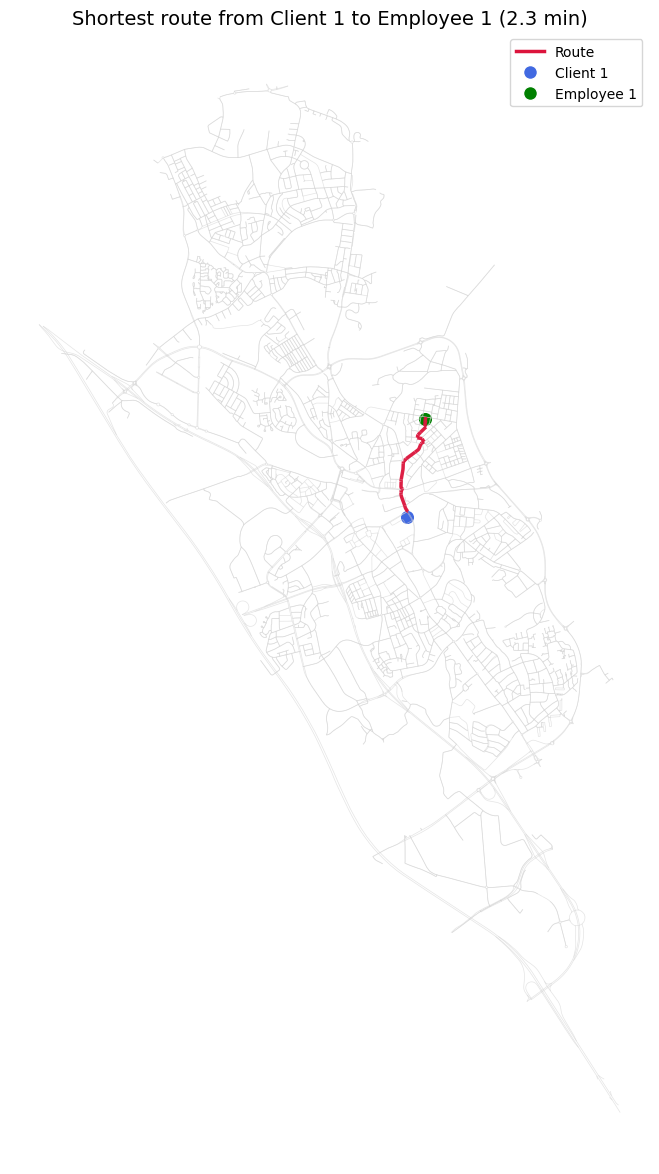

In [59]:
# Example usage and plot.
def _row_point(frame, row_index):
    row = frame.iloc[row_index]
    if "geometry" in frame.columns and row.get("geometry") is not None:
        return row["geometry"]
    if "lat" in frame.columns and "lon" in frame.columns:
        return gpd.points_from_xy([row["lon"]], [row["lat"]])[0]
    if "coordinates" in frame.columns:
        parts = str(row["coordinates"]).strip().split()
        if len(parts) != 2:
            raise ValueError("coordinates must contain two values: latitude and longitude.")
        lat_value = float(parts[0])
        lon_value = float(parts[1])
        return gpd.points_from_xy([lon_value], [lat_value])[0]
    raise ValueError("No point location columns found for this row.")

start_node = int(clients_df.iloc[0]["u"])
end_node = int(employees_df.iloc[0]["u"])
route_info = get_route_between_nodes(
    road_graph,
    start_node,
    end_node,
    weight="travel_time_min",
)

print(route_info["path_nodes"])
print(route_info["route_value"])

route_gdf = gpd.GeoDataFrame(
    geometry=route_info["route_geometries"],
    crs="EPSG:4326",
).to_crs(epsg=3857)
edges_plot = edges_gdf.to_crs(epsg=3857)

start_point = gpd.GeoSeries([_row_point(clients_df, 0)], crs="EPSG:4326").to_crs(epsg=3857)
end_point = gpd.GeoSeries([_row_point(employees_df, 0)], crs="EPSG:4326").to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(12, 12))
edges_plot.plot(ax=ax, color="lightgray", linewidth=0.5, alpha=0.6)
route_gdf.plot(ax=ax, color="crimson", linewidth=2.5, alpha=0.95)
start_point.plot(ax=ax, color="royalblue", markersize=70, alpha=1.0)
end_point.plot(ax=ax, color="green", markersize=70, alpha=1.0)

from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], color="crimson", lw=2.5, label="Route"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="royalblue", markersize=10, label="Client 1"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="green", markersize=10, label="Employee 1"),
]
ax.legend(handles=legend_handles, loc="best")

ax.set_title(
    f"Shortest route from Client 1 to Employee 1 ({route_info['route_value']:.1f} min)",
    fontsize=14,
)
ax.set_axis_off()
plt.tight_layout()
plt.show()

In [60]:
# Calculate fitness using heerlen_edge_table travel-time columns plus client care time.
def _ensure_points_gdf(frame):
    frame_copy = frame.copy()
    if "geometry" in frame_copy.columns:
        return gpd.GeoDataFrame(frame_copy, geometry="geometry", crs="EPSG:4326")

    if "coordinates" in frame_copy.columns:
        coordinate_parts = frame_copy["coordinates"].astype(str).str.strip().str.split(r"\s+", n=1, expand=True)
        if coordinate_parts.shape[1] != 2:
            raise ValueError("coordinates must contain latitude and longitude separated by a space.")
        frame_copy["lat"] = pd.to_numeric(coordinate_parts[0], errors="coerce")
        frame_copy["lon"] = pd.to_numeric(coordinate_parts[1], errors="coerce")
        return gpd.GeoDataFrame(
            frame_copy,
            geometry=gpd.points_from_xy(frame_copy["lon"], frame_copy["lat"]),
            crs="EPSG:4326",
        )

    lon_col = next((c for c in ["lon", "longitude", "x"] if c in frame_copy.columns), None)
    lat_col = next((c for c in ["lat", "latitude", "y"] if c in frame_copy.columns), None)
    if lon_col is None or lat_col is None:
        raise ValueError("Frame needs either geometry, coordinates, or lon/lat columns.")
    return gpd.GeoDataFrame(
        frame_copy,
        geometry=gpd.points_from_xy(frame_copy[lon_col], frame_copy[lat_col]),
        crs="EPSG:4326",
    )

def _build_travel_graph_from_edge_table(edge_table, weight_column):
    if weight_column not in edge_table.columns:
        raise ValueError(f"Column '{weight_column}' not found in heerlen_edge_table.")

    travel_graph = nx.DiGraph()
    required_columns = ["u", "v", weight_column]
    for col in required_columns:
        if col not in edge_table.columns:
            raise ValueError(f"Column '{col}' not found in heerlen_edge_table.")

    for row in edge_table[["u", "v", weight_column]].dropna().itertuples(index=False):
        node_u = int(row[0])
        node_v = int(row[1])
        edge_weight = float(row[2])
        if edge_weight < 0:
            continue

        if travel_graph.has_edge(node_u, node_v):
            travel_graph[node_u][node_v]["weight"] = min(travel_graph[node_u][node_v]["weight"], edge_weight)
        else:
            travel_graph.add_edge(node_u, node_v, weight=edge_weight)

    return travel_graph

def _candidate_nodes_from_row(row):
    candidates = []
    for column_name in ["u", "v"]:
        if column_name in row.index and pd.notna(row[column_name]):
            candidates.append(int(row[column_name]))
    return list(dict.fromkeys(candidates))

def _best_path_between_candidates(travel_graph, from_nodes, to_nodes):
    best_time = float("inf")
    best_path = None
    best_start = None
    best_end = None

    for start_node in from_nodes:
        for end_node in to_nodes:
            if start_node == end_node:
                candidate_path = [int(start_node)]
                candidate_time = 0.0
            else:
                try:
                    candidate_path = nx.shortest_path(
                        travel_graph,
                        start_node,
                        end_node,
                        weight="weight",
                    )
                    candidate_time = nx.path_weight(travel_graph, candidate_path, weight="weight")
                except (nx.NetworkXNoPath, nx.NodeNotFound):
                    continue

            if float(candidate_time) < best_time:
                best_time = float(candidate_time)
                best_path = [int(node_id) for node_id in candidate_path]
                best_start = int(start_node)
                best_end = int(end_node)

    return best_time, best_path, best_start, best_end

def _care_time_in_weight_units(care_hours, weight_column):
    if pd.isna(care_hours):
        return 0.0
    care_hours = max(0.0, float(care_hours))
    weight_name = str(weight_column).lower()
    if "sec" in weight_name or weight_name.endswith("_s") or "seconds" in weight_name:
        return care_hours * 3600.0
    return care_hours * 60.0

def _parse_time_value_to_minutes(value):
    if pd.isna(value):
        return None
    if isinstance(value, (int, float, np.integer, np.floating)):
        numeric_value = float(value)
        if numeric_value > 24 * 60:
            return numeric_value / 60.0
        return numeric_value
    text_value = str(value).strip()
    if not text_value:
        return None
    parsed = pd.to_datetime(text_value, errors="coerce")
    if pd.isna(parsed):
        return None
    return float(parsed.hour * 60 + parsed.minute + parsed.second / 60.0)

def _employee_available_time_units(employee_row, weight_column):
    start_minutes = _parse_time_value_to_minutes(employee_row.get("time_window_start"))
    end_minutes = _parse_time_value_to_minutes(employee_row.get("time_window_end"))
    if start_minutes is None or end_minutes is None:
        raise ValueError("Employee row must contain time_window_start and time_window_end.")

    available_minutes = max(0.0, end_minutes - start_minutes - 60.0)
    weight_name = str(weight_column).lower()
    if "sec" in weight_name or weight_name.endswith("_s") or "seconds" in weight_name:
        return available_minutes * 60.0
    return available_minutes

clients_gdf = _ensure_points_gdf(clients_df)
employees_gdf = _ensure_points_gdf(employees_df)

def calculate_fitness_score(
    heerlen_edge_table,
    clients_gdf,
    employees_gdf,
    route_client_indices,
    start_index=0,
    end_index=None,
    weight_column="travel_time_min",
    employee_index=0,
):
    """
    Calculate fitness for home -> selected clients -> home,
    stopping before the route exceeds the employee work window.

    Returns travel time, care time, total time, followed node path,
    and the route segment that could not be scheduled within the work window.
    """
    ordered_indices = list(route_client_indices)
    if not ordered_indices:
        return {
            "total_travel_time": 0.0,
            "total_care_time": 0.0,
            "total_time": 0.0,
            "full_path_nodes": [],
            "legs": [],
            "served_client_indices": [],
            "served_end_index": None,
            "work_time_limit": 0.0,
            "employee_index": int(employee_index),
            "employee_name": None,
        }

    if start_index < 0:
        raise ValueError("start_index must be >= 0.")
    if end_index is None:
        end_index = len(ordered_indices) - 1
    if end_index >= len(ordered_indices):
        raise ValueError("end_index is out of range for route_client_indices.")
    if start_index > end_index:
        raise ValueError("start_index and end_index must satisfy start_index <= end_index.")

    selected_route = ordered_indices[start_index : end_index + 1]
    if not selected_route:
        return {
            "total_travel_time": 0.0,
            "total_care_time": 0.0,
            "total_time": 0.0,
            "full_path_nodes": [],
            "legs": [],
            "served_client_indices": [],
            "served_end_index": None,
            "work_time_limit": 0.0,
            "employee_index": int(employee_index),
            "employee_name": None,
        }

    employee_index = int(employee_index)
    if employee_index < 0 or employee_index >= len(employees_gdf):
        raise ValueError("employee_index is out of range for employees_gdf.")

    travel_graph = _build_travel_graph_from_edge_table(heerlen_edge_table, weight_column)

    home_row = employees_gdf.iloc[employee_index]
    employee_name = str(home_row.get("name", employee_index))
    home_nodes = _candidate_nodes_from_row(home_row)
    if not home_nodes:
        raise ValueError("Employee row must contain at least one node column: u or v.")

    work_time_limit = _employee_available_time_units(home_row, weight_column)
    total_travel_time = 0.0
    total_care_time = 0.0
    current_nodes = home_nodes
    full_path_nodes = []
    legs = []
    served_client_indices = []

    for route_position, client_idx in enumerate(selected_route):
        client_row = clients_gdf.iloc[int(client_idx)]
        client_nodes = _candidate_nodes_from_row(client_row)
        client_name = str(client_row.get("name", client_idx))
        if not client_nodes:
            break

        leg_time, leg_path, leg_start, leg_end = _best_path_between_candidates(
            travel_graph, current_nodes, client_nodes
        )
        if not np.isfinite(leg_time) or leg_path is None:
            break

        care_time = _care_time_in_weight_units(client_row.get("care_hours", 0.0), weight_column)
        return_time, return_path, return_start, return_end = _best_path_between_candidates(
            travel_graph, client_nodes, home_nodes
        )
        if not np.isfinite(return_time) or return_path is None:
            break

        candidate_total = total_travel_time + leg_time + return_time + total_care_time + care_time
        if candidate_total > work_time_limit:
            break

        total_travel_time += leg_time
        total_care_time += care_time
        served_client_indices.append(int(client_idx))

        legs.append({
            "from_node": leg_start,
            "to_node": leg_end,
            "travel_time": leg_time,
            "care_time": care_time,
            "leg_total_time": leg_time + care_time,
            "path_nodes": leg_path,
            "kind": "to_client",
            "client_index": int(client_idx),
            "client_name": client_name,
        })

        if not full_path_nodes:
            full_path_nodes.extend(leg_path)
        else:
            full_path_nodes.extend(leg_path[1:])

        current_nodes = client_nodes

    return_time, return_path, return_start, return_end = _best_path_between_candidates(
        travel_graph, current_nodes, home_nodes
    )
    if np.isfinite(return_time) and return_path is not None:
        total_travel_time += return_time
        legs.append({
            "from_node": return_start,
            "to_node": return_end,
            "travel_time": return_time,
            "care_time": 0.0,
            "leg_total_time": return_time,
            "path_nodes": return_path,
            "kind": "return_home",
            "client_index": None,
            "client_name": None,
        })
        if not full_path_nodes:
            full_path_nodes.extend(return_path)
        else:
            full_path_nodes.extend(return_path[1:])

    total_time = total_travel_time + total_care_time
    return {
        "total_travel_time": total_travel_time,
        "total_care_time": total_care_time,
        "total_time": total_time,
        "full_path_nodes": full_path_nodes,
        "legs": legs,
        "served_client_indices": served_client_indices,
        "served_end_index": start_index + len(served_client_indices) - 1 if served_client_indices else None,
        "work_time_limit": work_time_limit,
        "employee_index": employee_index,
        "employee_name": employee_name,
    }

In [61]:
# Example usage: automatically fit as many clients as possible inside the employee work window.
fitness_result = calculate_fitness_score(
    heerlen_edge_table,
    clients_gdf,
    employees_gdf,
    initial_population[0],
    start_index=0,
    end_index=None,
    weight_column="travel_time_min",
    employee_index=0,
 )
fitness_travel_time = fitness_result["total_travel_time"]
fitness_care_time = fitness_result["total_care_time"]
fitness_score = fitness_result["total_time"]
fitness_path = fitness_result["full_path_nodes"]
fitness_legs = fitness_result["legs"]
served_client_indices = fitness_result["served_client_indices"]
served_end_index = fitness_result["served_end_index"]
work_time_limit = fitness_result["work_time_limit"]

In [62]:
# Assign clients to employees in sequence and continue with the remaining client list when an employee is full.
def assign_clients_to_employees_sequentially(
    heerlen_edge_table,
    clients_gdf,
    employees_gdf,
    route_client_indices,
    weight_column="travel_time_min",
):
    remaining_client_indices = list(route_client_indices)
    assignments = []

    for employee_index in range(len(employees_gdf)):
        if not remaining_client_indices:
            break

        employee_row = employees_gdf.iloc[employee_index]
        employee_name = str(employee_row.get("name", employee_index))
        fitness_result = calculate_fitness_score(
            heerlen_edge_table,
            clients_gdf,
            employees_gdf,
            remaining_client_indices,
            start_index=0,
            end_index=None,
            weight_column=weight_column,
            employee_index=employee_index,
        )

        served_client_indices = fitness_result["served_client_indices"]
        served_count = len(served_client_indices)
        assignments.append({
            "employee_index": employee_index,
            "employee_name": employee_name,
            "served_client_indices": served_client_indices,
            "fitness_result": fitness_result,
        })

        if served_count > 0:
            remaining_client_indices = remaining_client_indices[served_count:]

    return {
        "assignments": assignments,
        "remaining_client_indices": remaining_client_indices,
        "total_travel_time": sum(item["fitness_result"]["total_travel_time"] for item in assignments),
        "total_care_time": sum(item["fitness_result"]["total_care_time"] for item in assignments),
        "total_time": sum(item["fitness_result"]["total_time"] for item in assignments),
    }

In [63]:
sequential_assignment = assign_clients_to_employees_sequentially(
    heerlen_edge_table,
    clients_gdf,
    employees_gdf,
    initial_population[0],
    weight_column="travel_time_min",
 )

for assignment in sequential_assignment["assignments"]:
    print(f"{assignment['employee_name']}: {assignment['served_client_indices']}")

print("Remaining clients:", sequential_assignment["remaining_client_indices"])
sequential_assignment

employee 1: [105, 108, 142, 55]
employee 1: [94, 29, 101, 51, 100]
employee 2: [143, 19, 84, 15]
employee 2: [66, 24, 30, 128]
employee 3: [148, 98, 16, 75]
employee 4: [18, 12, 9, 31]
employee 5: [152, 97, 56, 132]
employee 6: [104, 137, 78, 60]
employee 7: [115, 2, 123, 45]
employee 8: [42, 69, 90, 26]
employee 8: [139, 82, 96, 131, 36]
employee 9: [81, 22, 144, 67, 114]
employee 10: [11, 65, 85, 6]
employee 10: [27, 76, 140, 126]
employee 11: [41, 4, 136, 32]
employee 12: [127, 133, 68, 10]
employee 12: [95, 109, 0]
employee 13: [119, 111, 64, 44, 86]
employee 13: [28, 40, 112, 25, 23]
employee 14: [117, 79, 39, 93, 157]
employee 14: [156, 135, 47, 153, 61]
employee 15: [73, 33, 120, 118]
employee 15: [125, 62, 159, 149]
employee 16: [154, 53, 5]
employee 16: [150, 124, 49, 35]
employee 17: [80, 77, 34, 46]
employee 17: [7, 43, 70, 122, 110]
employee 18: [91, 83, 145, 146]
employee 18: [89, 8, 113, 13, 59]
employee 19: [138, 3, 17, 38]
employee 19: [72, 141, 134, 147, 63]
employee 2

{'assignments': [{'employee_index': 0,
   'employee_name': 'employee 1',
   'served_client_indices': [105, 108, 142, 55],
   'fitness_result': {'total_travel_time': 19.924452363014257,
    'total_care_time': 480.0,
    'total_time': 499.92445236301427,
    'full_path_nodes': [42044822,
     42044627,
     4995414674,
     42043743,
     42043394,
     42042819,
     42042707,
     42041823,
     3126377818,
     42041009,
     42041089,
     42041065,
     1724265755,
     1724265680,
     42040720,
     1724265735,
     42038089,
     42037530,
     11070185574,
     694343749,
     694343752,
     11070185578,
     1928612561,
     3501091499,
     42035244,
     8832515619,
     42033706,
     42033003,
     42032089,
     42029920,
     42029001,
     1263350306,
     1263350309,
     42028016,
     42027690,
     42026488,
     42025519,
     42023911,
     42022955,
     42022088,
     42021705,
     42019912,
     42021705,
     42022088,
     42022955,
     42023911,
     42025

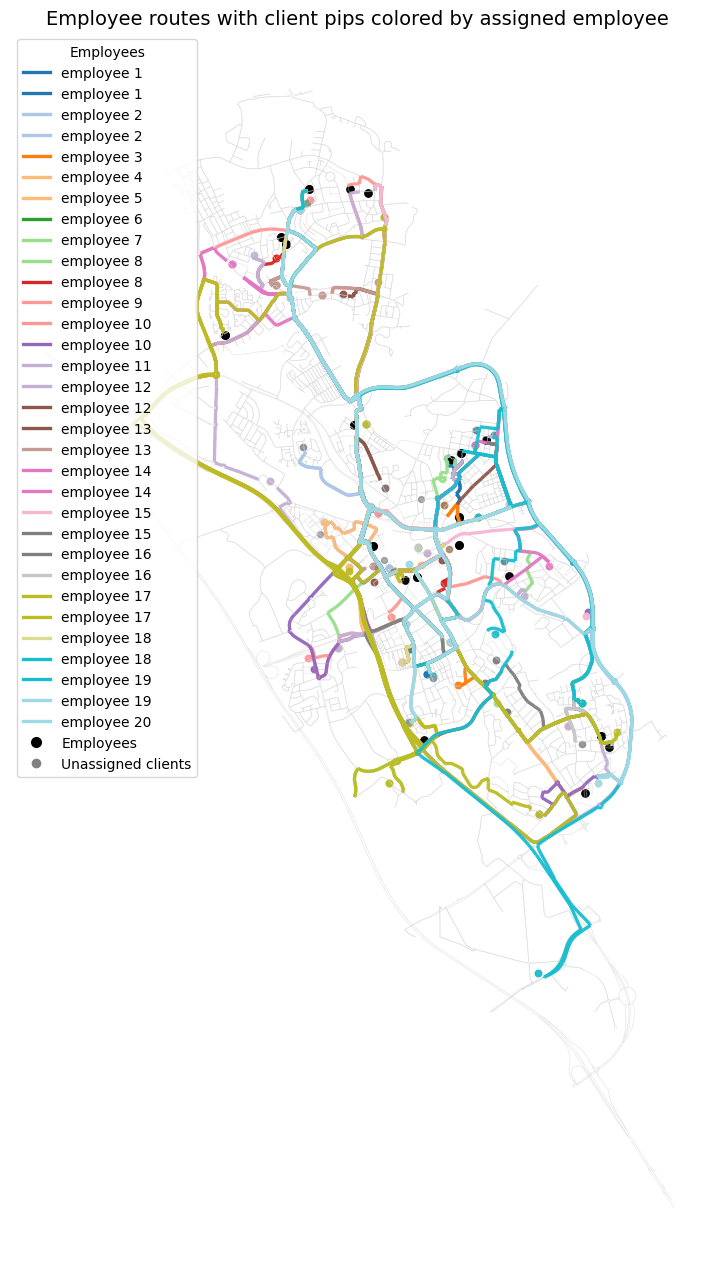

In [ ]:
# Visualize routing using the color of the employee
from matplotlib.lines import Line2D

# Copy of the route plot with adjusted pip colors:
# - employee pips are black
# - client pips use the color of their assigned employee
def _route_geometries_from_path_nodes_colored(graph, path_nodes, weight="travel_time_min"):
    route_geometries = []
    for node_u, node_v in pairwise(path_nodes):
        edge_bundle = graph.get_edge_data(node_u, node_v)
        if not edge_bundle:
            route_geometries.append(
                LineString(
                    [
                        (graph.nodes[node_u]["x"], graph.nodes[node_u]["y"]),
                        (graph.nodes[node_v]["x"], graph.nodes[node_v]["y"]),
                    ]
                )
            )
            continue

        best_key = min(
            edge_bundle,
            key=lambda candidate_key: edge_bundle[candidate_key].get(weight, float("inf")),
        )
        selected_edge = edge_bundle[best_key]
        geometry = selected_edge.get("geometry")
        if geometry is None or geometry.is_empty:
            geometry = LineString(
                [
                    (graph.nodes[node_u]["x"], graph.nodes[node_u]["y"]),
                    (graph.nodes[node_v]["x"], graph.nodes[node_v]["y"]),
                ]
            )
        route_geometries.append(geometry)

    return route_geometries

edges_plot = edges_gdf.to_crs(epsg=3857)
clients_plot = clients_gdf.to_crs(epsg=3857)
employee_points = employees_gdf.to_crs(epsg=3857)
plot_colors = plt.get_cmap("tab20", max(1, len(sequential_assignment["assignments"])))

fig, ax = plt.subplots(figsize=(13, 13))
edges_plot.plot(ax=ax, color="lightgray", linewidth=0.5, alpha=0.55)

legend_handles = []
client_color_map = {}

for idx, assignment in enumerate(sequential_assignment["assignments"]):
    color = plot_colors(idx)
    route_geometries = []

    for leg in assignment["fitness_result"]["legs"]:
        path_nodes = leg.get("path_nodes") or []
        if len(path_nodes) < 2:
            continue
        route_geometries.extend(
            _route_geometries_from_path_nodes_colored(
                road_graph,
                path_nodes,
                weight="travel_time_min",
            )
        )

    served_indices = assignment.get("served_client_indices", [])
    for client_idx in served_indices:
        client_color_map[int(client_idx)] = color

    if route_geometries:
        route_gdf = gpd.GeoDataFrame(geometry=route_geometries, crs="EPSG:4326").to_crs(epsg=3857)
        route_gdf.plot(ax=ax, color=color, linewidth=2.4, alpha=0.95)

    legend_handles.append(Line2D([0], [0], color=color, lw=2.4, label=assignment["employee_name"]))

# Plot each client's pip in the color of their assigned employee
for client_idx, color in client_color_map.items():
    if 0 <= client_idx < len(clients_plot):
        clients_plot.iloc[[client_idx]].plot(ax=ax, color=color, markersize=22, alpha=0.95)

# Optional: show unassigned clients in gray if any
unassigned_indices = [i for i in range(len(clients_plot)) if i not in client_color_map]
if unassigned_indices:
    clients_plot.iloc[unassigned_indices].plot(ax=ax, color="gray", markersize=18, alpha=0.65)

# Employee pips in black
employee_points.plot(ax=ax, color="black", markersize=28, alpha=0.95)

legend_handles.extend([
    Line2D([0], [0], marker="o", color="w", markerfacecolor="black", markersize=9, label="Employees"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="gray", markersize=8, label="Unassigned clients"),
])

ax.set_title("Employee routes with client pips colored by assigned employee", fontsize=14)
ax.set_axis_off()
ax.legend(handles=legend_handles, loc="best", title="Employees")
plt.tight_layout()
plt.show()

In [69]:
# Test cell: running tally of client allocation in the first 100 clients.
test_client_count = 100
route_order = list(initial_population[0])
test_route = route_order[: min(test_client_count, len(route_order))]

# Re-run assignment only for this test window.
sequential_assignment_test = assign_clients_to_employees_sequentially(
    heerlen_edge_table,
    clients_gdf,
    employees_gdf,
    test_route,
    weight_column="travel_time_min",
)

total_in_test = len(test_route)
if total_in_test == 0:
    raise ValueError("Test route is empty, cannot compute allocation tally.")

print(f"=== CLIENT ALLOCATION TALLY (first {total_in_test} clients) ===")
print("Format: employee_name | this employee count | cumulative served | cumulative %")

cumulative_served = 0
for assignment in sequential_assignment_test["assignments"]:
    employee_name = assignment.get("employee_name", assignment.get("employee_index"))
    served = assignment.get("served_client_indices", [])
    employee_count = len(served)
    cumulative_served += employee_count
    cumulative_pct = cumulative_served / total_in_test * 100.0

    print(
        f"{employee_name} | +{employee_count} | total={cumulative_served} | {cumulative_pct:.1f}%"
    )

remaining_total = len(sequential_assignment_test["remaining_client_indices"])
remaining_pct = remaining_total / total_in_test * 100.0

print("\n=== FINAL SUMMARY ===")
print(f"Assigned: {cumulative_served}/{total_in_test} ({(cumulative_served / total_in_test * 100.0):.1f}%)")
print(f"Unassigned: {remaining_total}/{total_in_test} ({remaining_pct:.1f}%)")

if cumulative_served > 0:
    print(f"Last served position (0-based): {cumulative_served - 1}")
    print(f"Last served position (1-based): {cumulative_served}")

if remaining_total > 0:
    print(f"Next unassigned position (0-based): {cumulative_served}")
    print(f"Next unassigned position (1-based): {cumulative_served + 1}")
    print("Remaining client indices from the test list:")
    print(sequential_assignment_test["remaining_client_indices"])

=== CLIENT ALLOCATION TALLY (first 100 clients) ===
Format: employee_name | this employee count | cumulative served | cumulative %
employee 1 | +4 | total=4 | 4.0%
employee 1 | +5 | total=9 | 9.0%
employee 2 | +4 | total=13 | 13.0%
employee 2 | +4 | total=17 | 17.0%
employee 3 | +4 | total=21 | 21.0%
employee 4 | +4 | total=25 | 25.0%
employee 5 | +4 | total=29 | 29.0%
employee 6 | +4 | total=33 | 33.0%
employee 7 | +4 | total=37 | 37.0%
employee 8 | +4 | total=41 | 41.0%
employee 8 | +5 | total=46 | 46.0%
employee 9 | +5 | total=51 | 51.0%
employee 10 | +4 | total=55 | 55.0%
employee 10 | +4 | total=59 | 59.0%
employee 11 | +4 | total=63 | 63.0%
employee 12 | +4 | total=67 | 67.0%
employee 12 | +3 | total=70 | 70.0%
employee 13 | +5 | total=75 | 75.0%
employee 13 | +5 | total=80 | 80.0%
employee 14 | +5 | total=85 | 85.0%
employee 14 | +5 | total=90 | 90.0%
employee 15 | +4 | total=94 | 94.0%
employee 15 | +4 | total=98 | 98.0%
employee 16 | +2 | total=100 | 100.0%

=== FINAL SUMMARY 